In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/alzheimers_disease_data.csv')
df.head()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


In [ ]:
df.drop(['PatientID','DoctorInCharge'],axis=1,inplace=True)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True,inplace=True)

In [ ]:
df.shape

(2149, 33)

In [ ]:
df.isnull().sum().sort_values(ascending = False)

,0
Age,0
Gender,0
Ethnicity,0
EducationLevel,0
BMI,0
Smoking,0
AlcoholConsumption,0
PhysicalActivity,0
DietQuality,0
SleepQuality,0


In [ ]:
for col in df.select_dtypes(include=['object']).columns:
    print(f'number of column {col} is : ',df[col].nunique())
    print(f'number of column {col} is : ',df[col].unique())

In [ ]:
df.select_dtypes(include=['object']).columns

Index([], dtype='object')

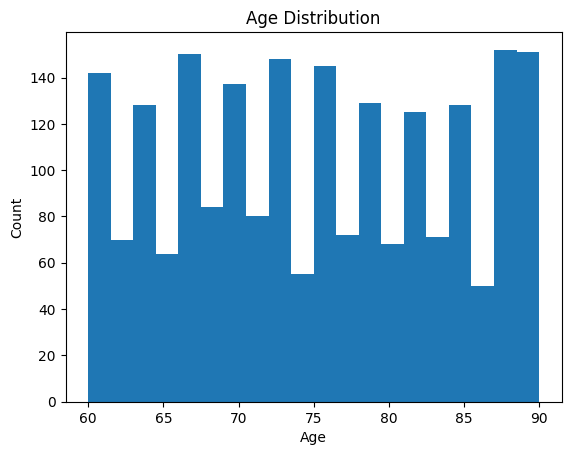

In [ ]:
plt.figure()
plt.hist(df["Age"], bins=20)
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age Distribution")
plt.show()

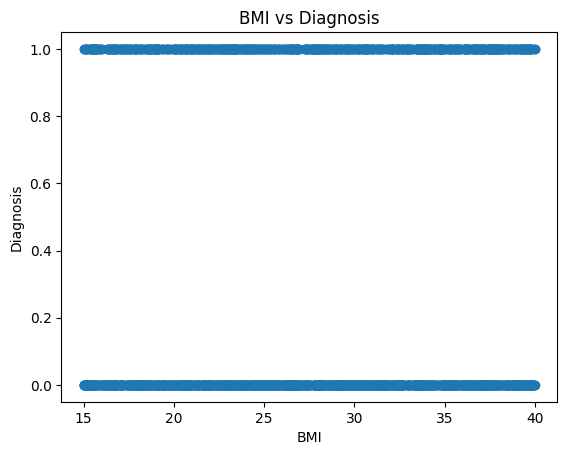

In [ ]:
plt.figure()
plt.scatter(df["BMI"], df["Diagnosis"])
plt.xlabel("BMI")
plt.ylabel("Diagnosis")
plt.title("BMI vs Diagnosis")
plt.show()

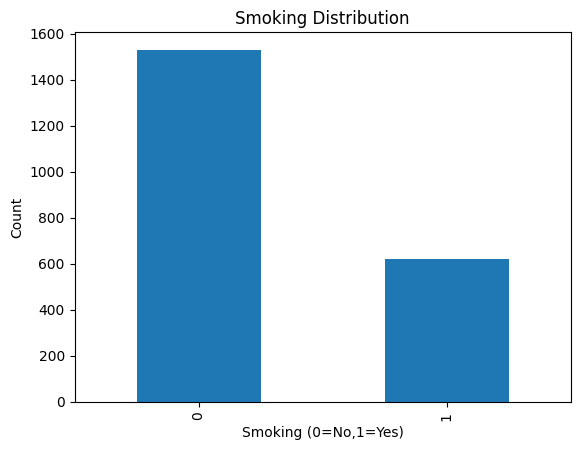

In [ ]:
plt.figure()
df["Smoking"].value_counts().plot(kind="bar")
plt.xlabel("Smoking (0=No,1=Yes)")
plt.ylabel("Count")
plt.title("Smoking Distribution")
plt.show()


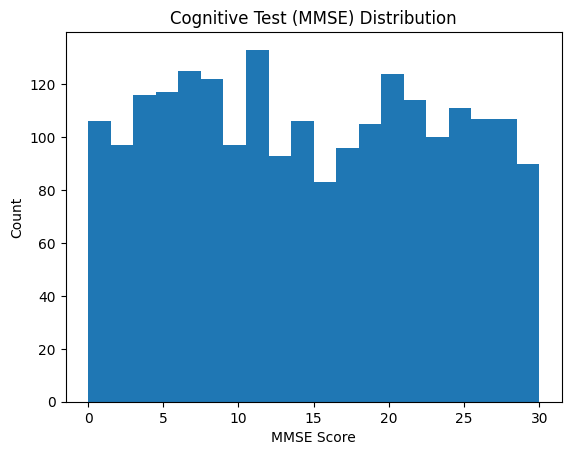

In [ ]:
plt.figure()
plt.hist(df["MMSE"], bins=20)
plt.xlabel("MMSE Score")
plt.ylabel("Count")
plt.title("Cognitive Test (MMSE) Distribution")
plt.show()


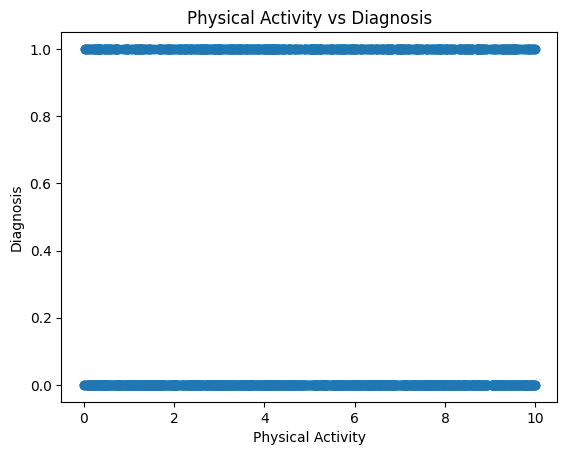

In [ ]:
plt.figure()
plt.scatter(df["PhysicalActivity"], df["Diagnosis"])
plt.xlabel("Physical Activity")
plt.ylabel("Diagnosis")
plt.title("Physical Activity vs Diagnosis")
plt.show()

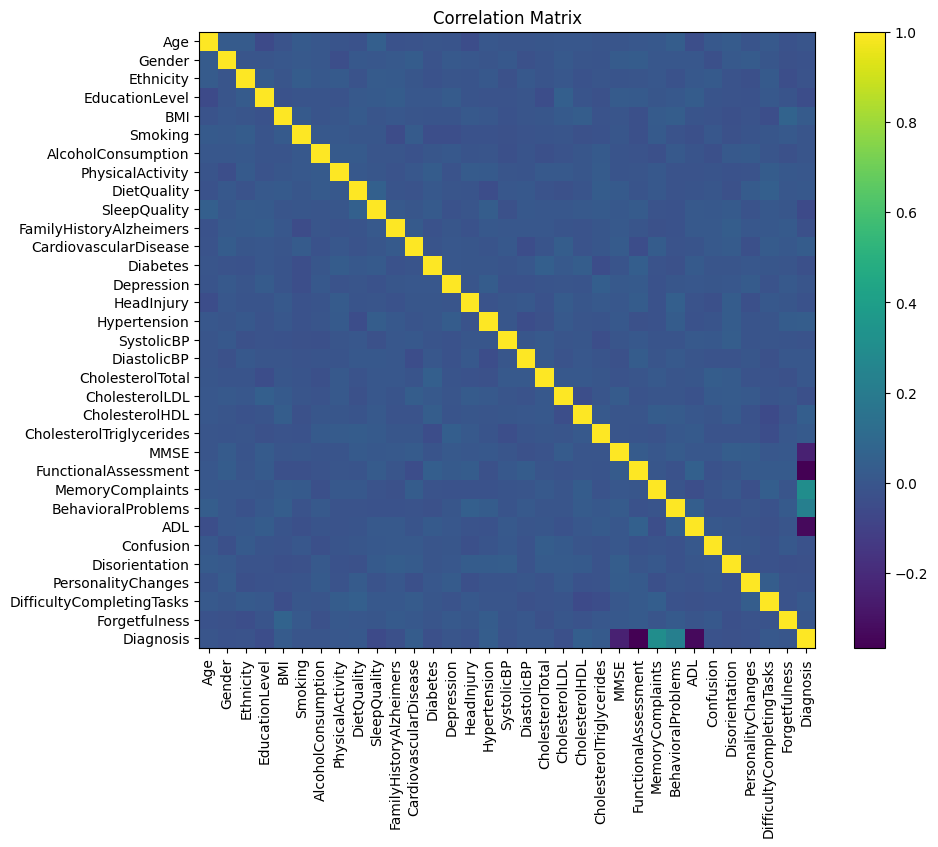

In [ ]:
corr = df.corr()

plt.figure(figsize=(10,8))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.show()

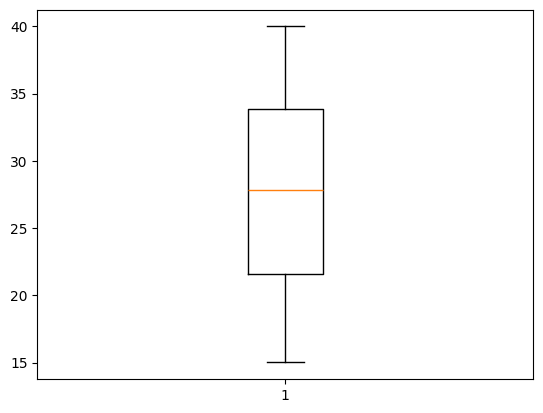

In [ ]:
plt.boxplot(df['BMI'])
plt.show()

In [ ]:
def remove_outliers_iqr(data, column_name="value"):
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[column_name] >= lower) & (df[column_name] <= upper)]
cleaned_df = remove_outliers_iqr(df, column_name="Smoking")

print(df.shape,cleaned_df.shape)

(2149, 33) (2149, 33)


In [ ]:
X=df.drop(['Diagnosis'],axis=1)

In [ ]:
y=df['Diagnosis']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,
                                   test_size= 0.20, random_state=100, stratify=None)

print("X_train = ",X_train.shape ," y_train = ", y_train.shape)
print("X_test  = ",X_test.shape ," y_test  = ", y_test.shape)

X_train =  (1719, 32)  y_train =  (1719,)
X_test  =  (430, 32)  y_test  =  (430,)


In [ ]:
from sklearn.preprocessing import StandardScaler
my_scaler = StandardScaler()
X_train[['Smoking']] = my_scaler.fit_transform(X_train[['Smoking']])
X_test[['Smoking']] = my_scaler.transform(X_test[['Smoking']])
X_train['Smoking'].min(),X_train['Smoking'].max()

(-0.6458696215283627, 1.5483001006203634)

In [ ]:
from tqdm import tqdm
!pip install xgboost lightgbm catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.2 MB/s eta 0:00:00


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.naive_bayes import GaussianNB

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier
)

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    balanced_accuracy_score,
    roc_auc_score,roc_curve,
    precision_recall_curve,average_precision_score
)

In [ ]:
models={
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=1),


    "KNN": KNeighborsClassifier(n_neighbors=5),


    #"SVC": SVC(probability=True, random_state=1,kernel='rbf',C=1,gamma=1),


    "Decision Tree": DecisionTreeClassifier(random_state=1),


    "Naive Bayes": GaussianNB(),


    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=1),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100, random_state=1),


    "AdaBoost": AdaBoostClassifier(random_state=1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=1),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(random_state=1),


    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=1, use_label_encoder=False),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=1),
    "LightGBM": LGBMClassifier(random_state=1)
}

  0%|          | 0/12 [00:00<?, ?it/s]


Confusion Matrix:
 [[254  28]
 [ 62  86]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


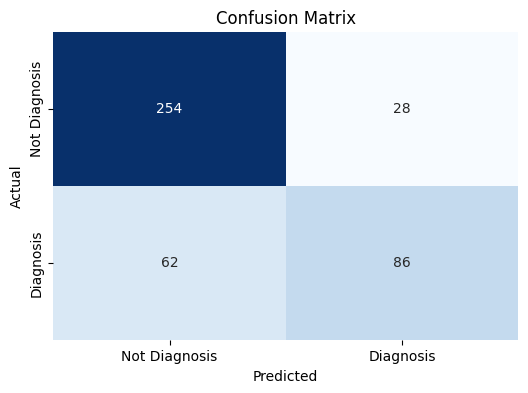


Classification Report:

               precision    recall  f1-score   support

Not Diagnosis       0.80      0.90      0.85       282
    Diagnosis       0.75      0.58      0.66       148

     accuracy                           0.79       430
    macro avg       0.78      0.74      0.75       430
 weighted avg       0.79      0.79      0.78       430

ROC-AUC: 0.8413599769982749


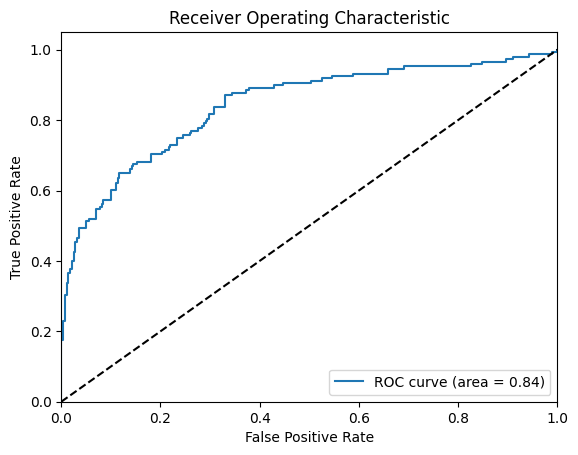

PR AUC: 0.7876092472768806


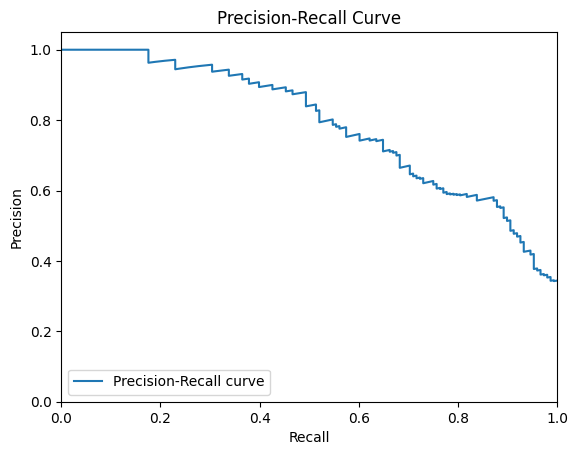

  8%|▊         | 1/12 [00:01<00:13,  1.25s/it]


Confusion Matrix:
 [[207  75]
 [ 99  49]]


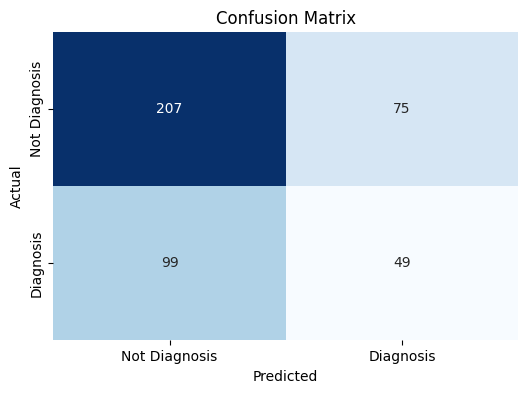


Classification Report:

               precision    recall  f1-score   support

Not Diagnosis       0.68      0.73      0.70       282
    Diagnosis       0.40      0.33      0.36       148

     accuracy                           0.60       430
    macro avg       0.54      0.53      0.53       430
 weighted avg       0.58      0.60      0.59       430

ROC-AUC: 0.5277578110024919


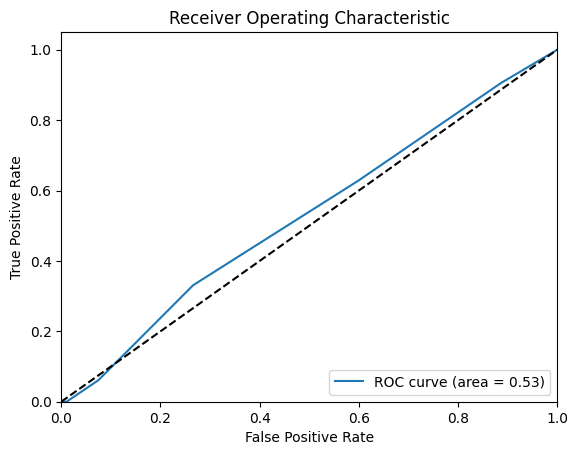

PR AUC: 0.359801814469052


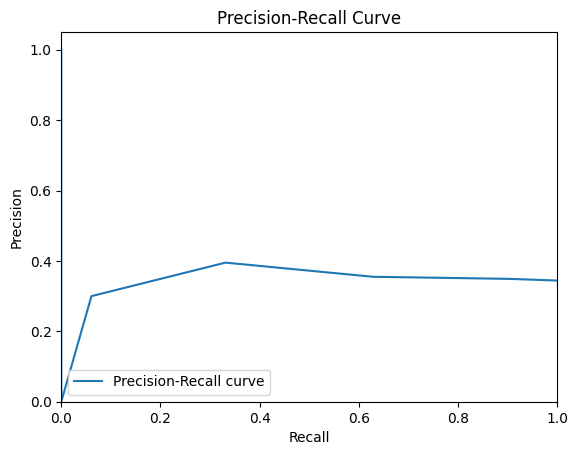

 17%|█▋        | 2/12 [00:01<00:07,  1.27it/s]


Confusion Matrix:
 [[259  23]
 [ 37 111]]


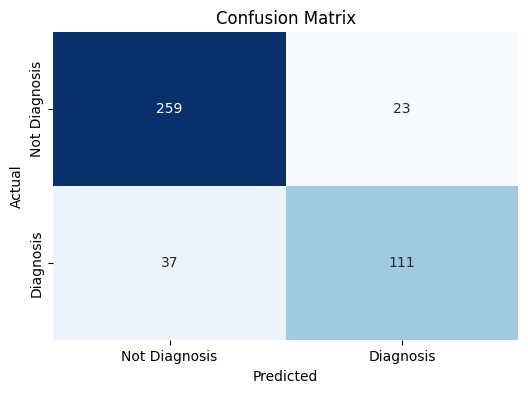


Classification Report:

               precision    recall  f1-score   support

Not Diagnosis       0.88      0.92      0.90       282
    Diagnosis       0.83      0.75      0.79       148

     accuracy                           0.86       430
    macro avg       0.85      0.83      0.84       430
 weighted avg       0.86      0.86      0.86       430

ROC-AUC: 0.8342198581560284


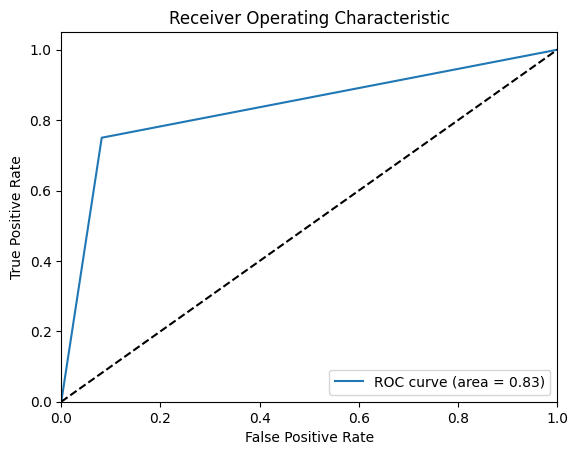

PR AUC: 0.7073151683443248


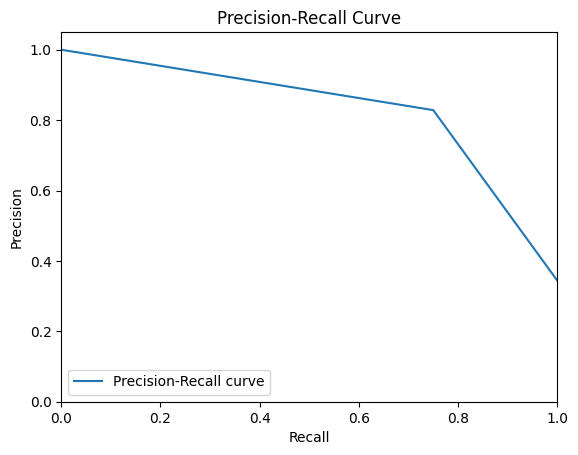

 25%|██▌       | 3/12 [00:02<00:05,  1.60it/s]


Confusion Matrix:
 [[244  38]
 [ 63  85]]


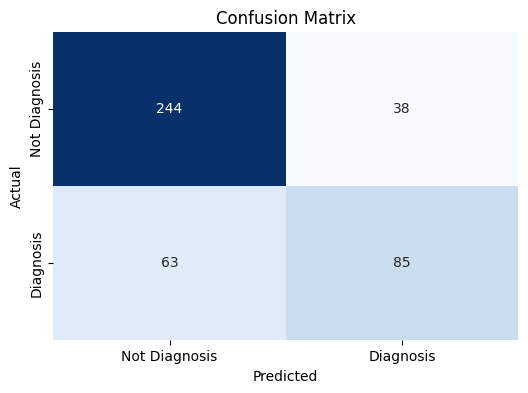


Classification Report:

               precision    recall  f1-score   support

Not Diagnosis       0.79      0.87      0.83       282
    Diagnosis       0.69      0.57      0.63       148

     accuracy                           0.77       430
    macro avg       0.74      0.72      0.73       430
 weighted avg       0.76      0.77      0.76       430

ROC-AUC: 0.8175675675675677


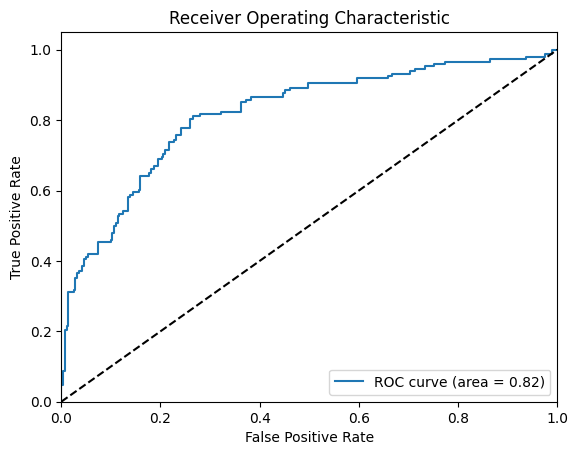

PR AUC: 0.7300396094933838


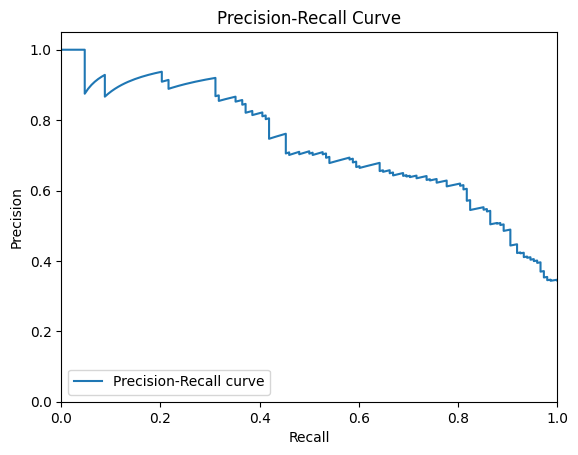

 33%|███▎      | 4/12 [00:02<00:04,  1.85it/s]


Confusion Matrix:
 [[276   6]
 [ 30 118]]


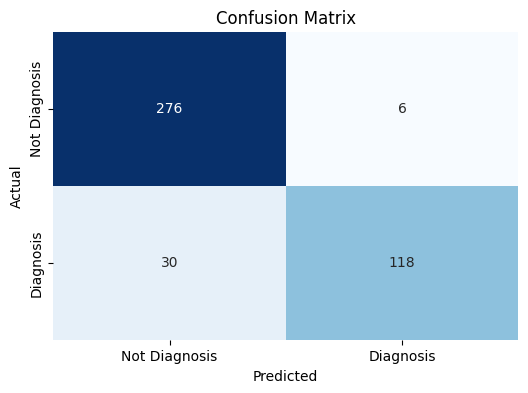


Classification Report:

               precision    recall  f1-score   support

Not Diagnosis       0.90      0.98      0.94       282
    Diagnosis       0.95      0.80      0.87       148

     accuracy                           0.92       430
    macro avg       0.93      0.89      0.90       430
 weighted avg       0.92      0.92      0.91       430

ROC-AUC: 0.9141987732413264


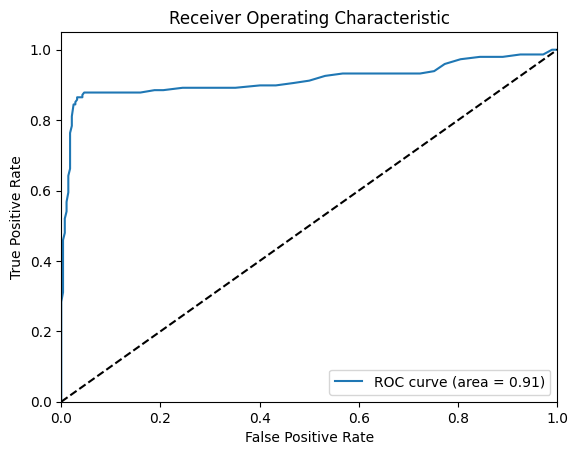

PR AUC: 0.9115979301028263


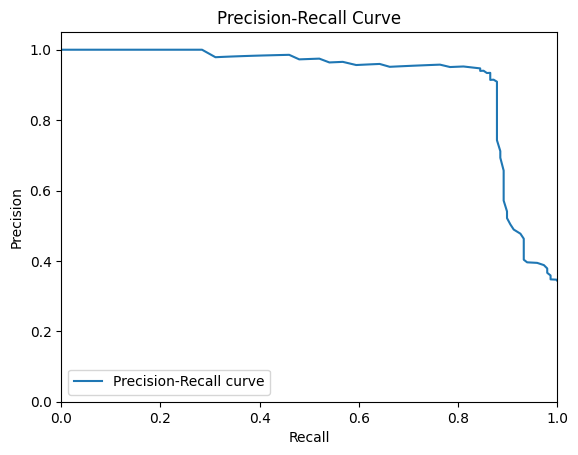

 42%|████▏     | 5/12 [00:03<00:05,  1.39it/s]


Confusion Matrix:
 [[269  13]
 [ 59  89]]


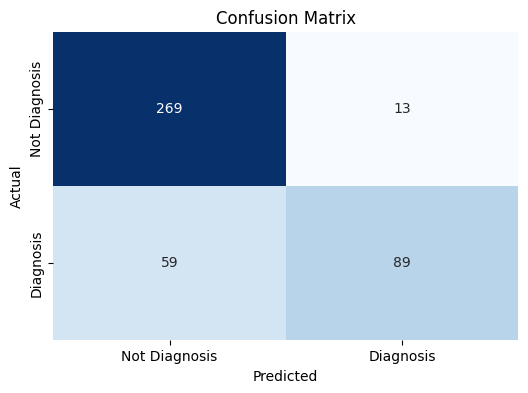


Classification Report:

               precision    recall  f1-score   support

Not Diagnosis       0.82      0.95      0.88       282
    Diagnosis       0.87      0.60      0.71       148

     accuracy                           0.83       430
    macro avg       0.85      0.78      0.80       430
 weighted avg       0.84      0.83      0.82       430

ROC-AUC: 0.8819484377995016


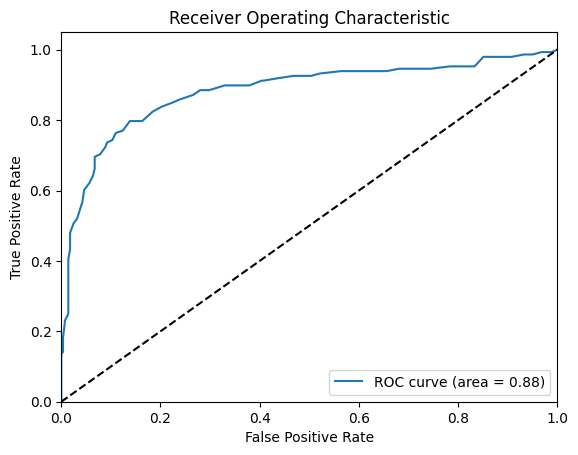

PR AUC: 0.8339230904683886


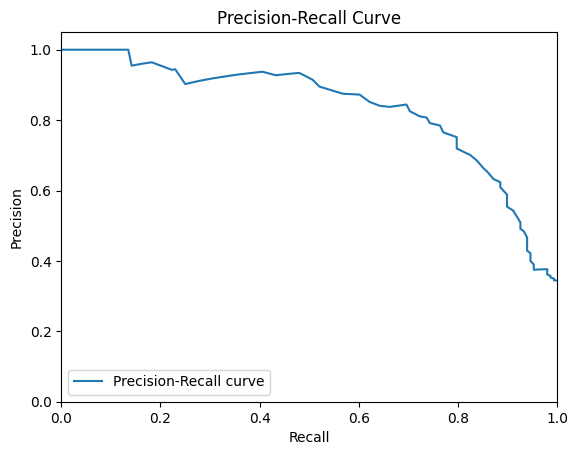

 50%|█████     | 6/12 [00:04<00:04,  1.34it/s]


Confusion Matrix:
 [[268  14]
 [ 28 120]]


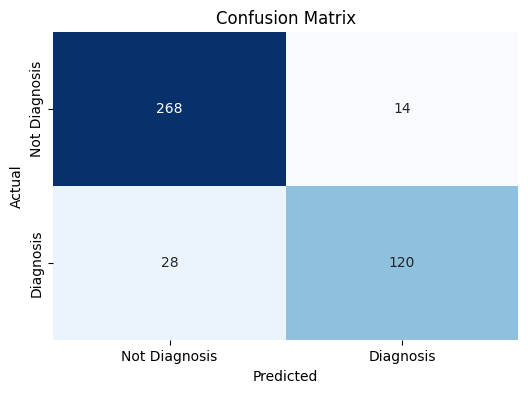


Classification Report:

               precision    recall  f1-score   support

Not Diagnosis       0.91      0.95      0.93       282
    Diagnosis       0.90      0.81      0.85       148

     accuracy                           0.90       430
    macro avg       0.90      0.88      0.89       430
 weighted avg       0.90      0.90      0.90       430

ROC-AUC: 0.9048782825378571


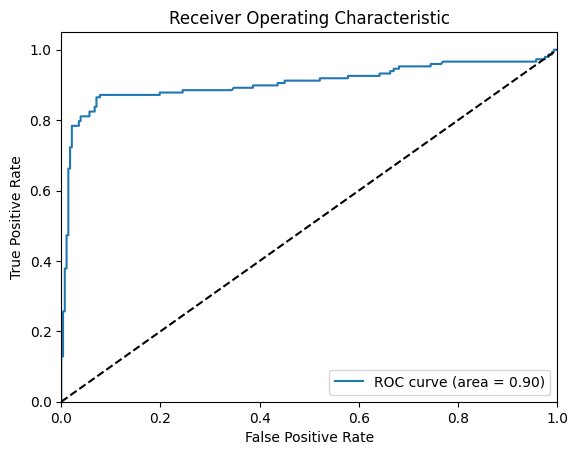

PR AUC: 0.8918766149771382


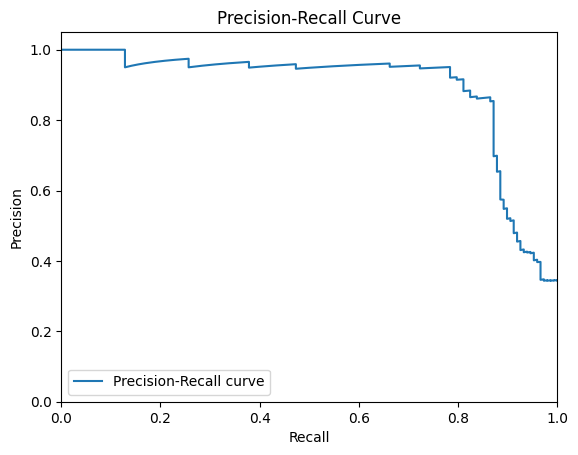

 58%|█████▊    | 7/12 [00:05<00:03,  1.33it/s]


Confusion Matrix:
 [[273   9]
 [ 24 124]]


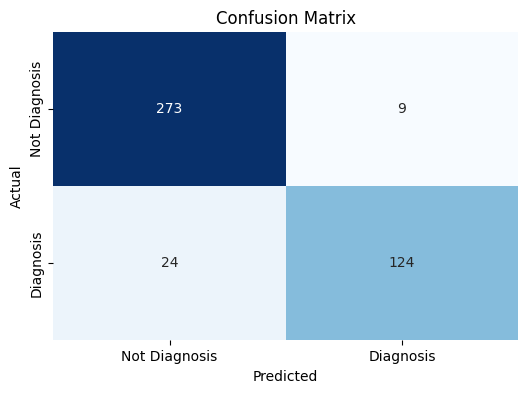


Classification Report:

               precision    recall  f1-score   support

Not Diagnosis       0.92      0.97      0.94       282
    Diagnosis       0.93      0.84      0.88       148

     accuracy                           0.92       430
    macro avg       0.93      0.90      0.91       430
 weighted avg       0.92      0.92      0.92       430

ROC-AUC: 0.9126892850297106


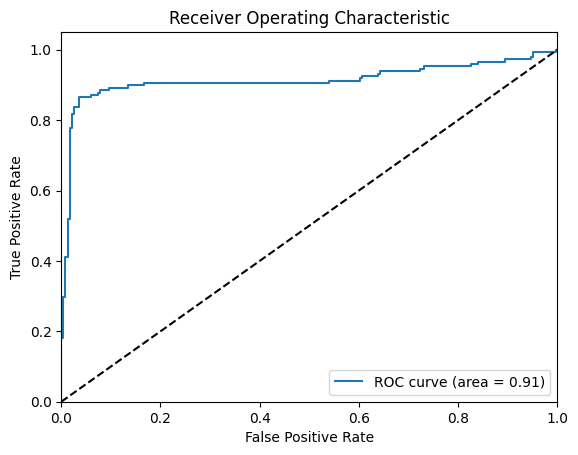

PR AUC: 0.9047978486749595


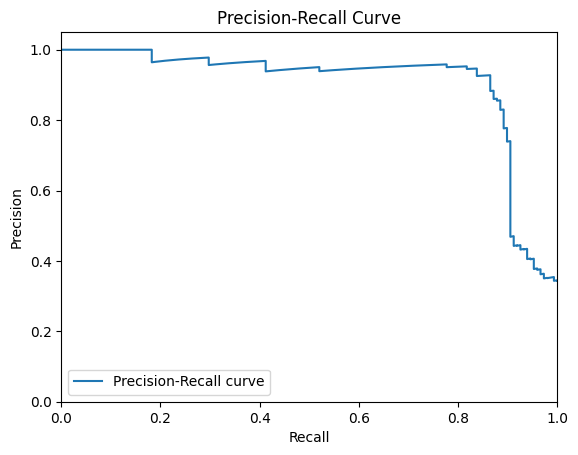

 67%|██████▋   | 8/12 [00:07<00:05,  1.27s/it]


Confusion Matrix:
 [[274   8]
 [ 25 123]]


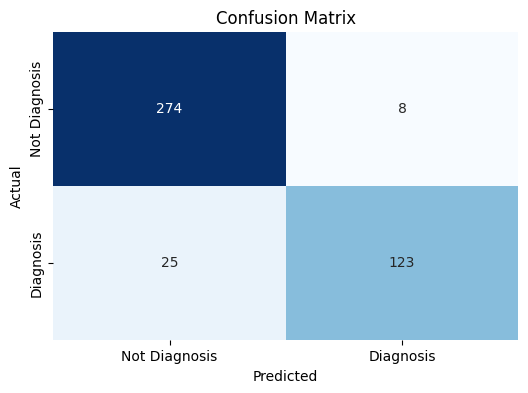


Classification Report:

               precision    recall  f1-score   support

Not Diagnosis       0.92      0.97      0.94       282
    Diagnosis       0.94      0.83      0.88       148

     accuracy                           0.92       430
    macro avg       0.93      0.90      0.91       430
 weighted avg       0.92      0.92      0.92       430

ROC-AUC: 0.9168823078397546


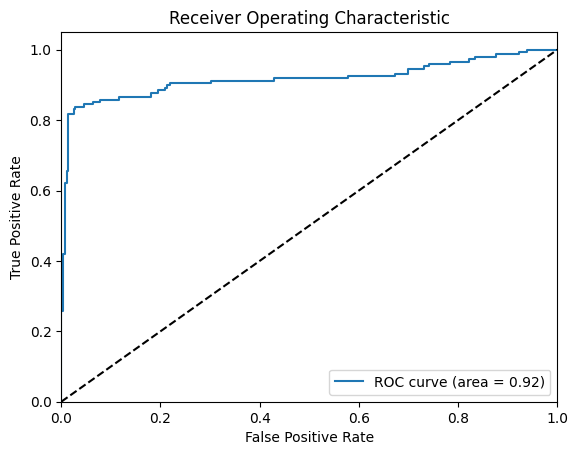

PR AUC: 0.9130444750755643


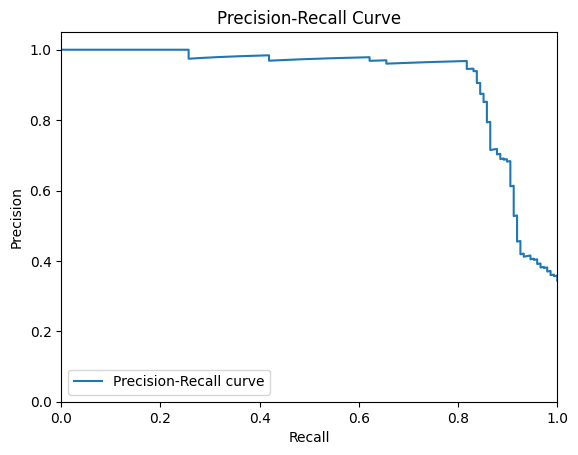

 75%|███████▌  | 9/12 [00:08<00:03,  1.24s/it]/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [20:52:21] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Confusion Matrix:
 [[276   6]
 [ 26 122]]


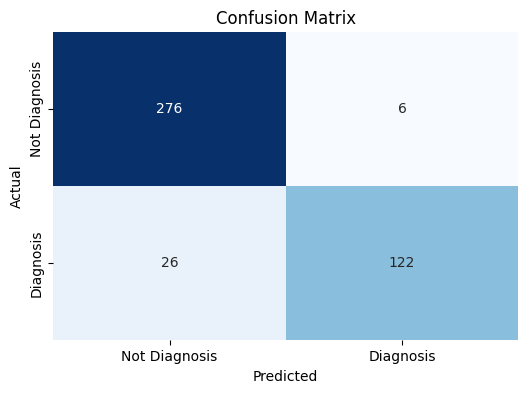


Classification Report:

               precision    recall  f1-score   support

Not Diagnosis       0.91      0.98      0.95       282
    Diagnosis       0.95      0.82      0.88       148

     accuracy                           0.93       430
    macro avg       0.93      0.90      0.91       430
 weighted avg       0.93      0.93      0.92       430

ROC-AUC: 0.9190387195706343


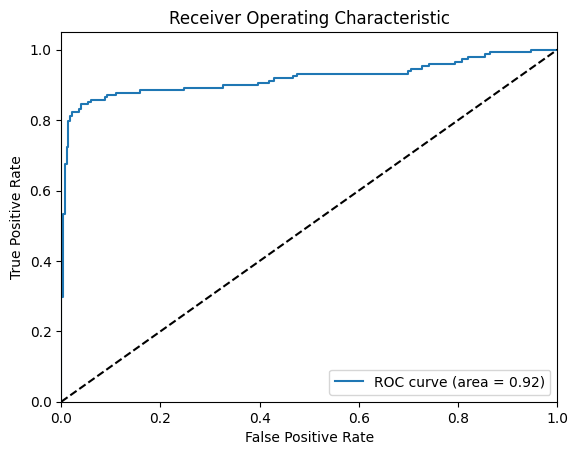

PR AUC: 0.9173119421744083


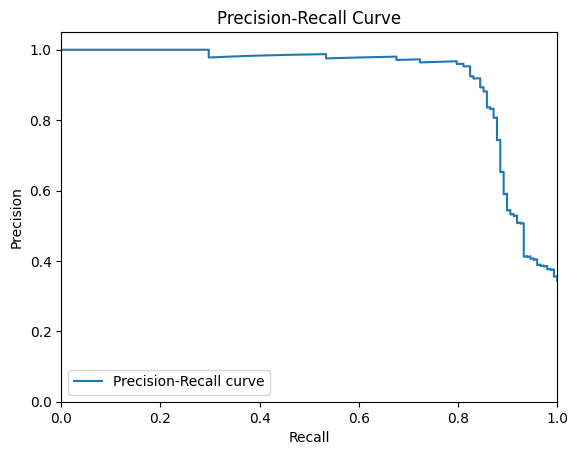

 83%|████████▎ | 10/12 [00:09<00:02,  1.07s/it]


Confusion Matrix:
 [[274   8]
 [ 20 128]]


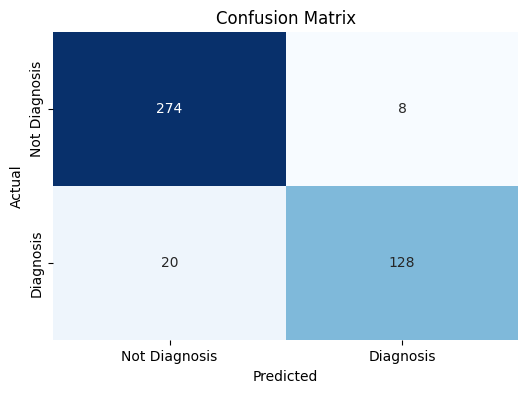


Classification Report:

               precision    recall  f1-score   support

Not Diagnosis       0.93      0.97      0.95       282
    Diagnosis       0.94      0.86      0.90       148

     accuracy                           0.93       430
    macro avg       0.94      0.92      0.93       430
 weighted avg       0.94      0.93      0.93       430

ROC-AUC: 0.9124496837262793


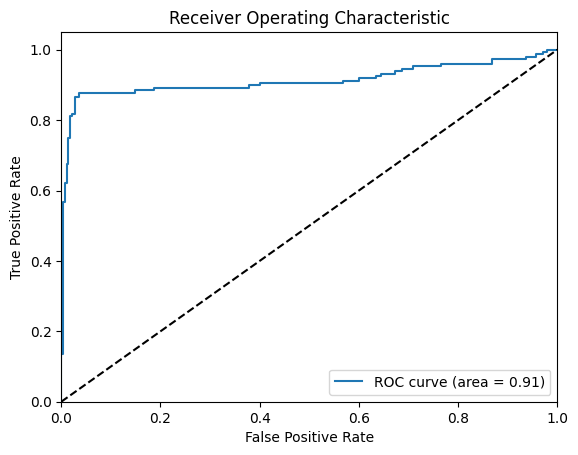

PR AUC: 0.9118053434228931


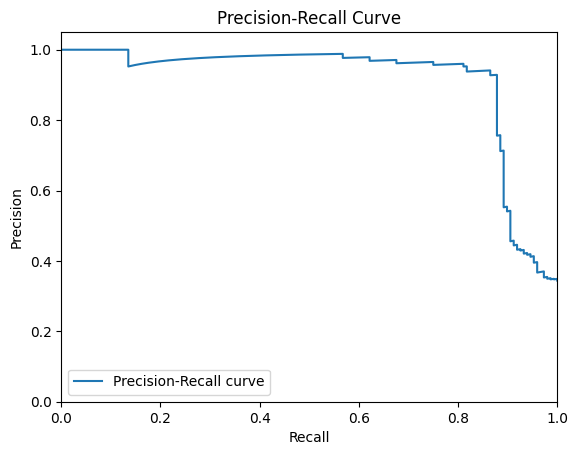

 92%|█████████▏| 11/12 [00:14<00:02,  2.24s/it]

[LightGBM] [Info] Number of positive: 612, number of negative: 1107
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000846 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3283
[LightGBM] [Info] Number of data points in the train set: 1719, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.356021 -> initscore=-0.592677
[LightGBM] [Info] Start training from score -0.592677

Confusion Matrix:
 [[273   9]
 [ 22 126]]


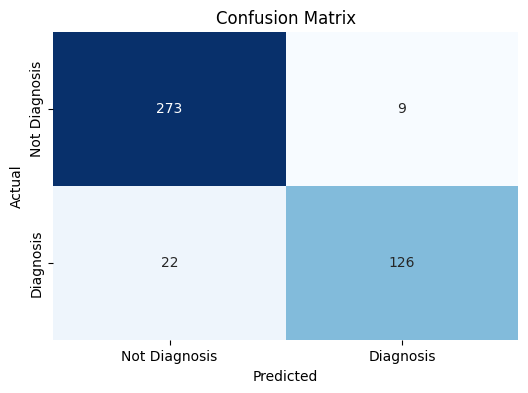


Classification Report:

               precision    recall  f1-score   support

Not Diagnosis       0.93      0.97      0.95       282
    Diagnosis       0.93      0.85      0.89       148

     accuracy                           0.93       430
    macro avg       0.93      0.91      0.92       430
 weighted avg       0.93      0.93      0.93       430

ROC-AUC: 0.9221774966455818


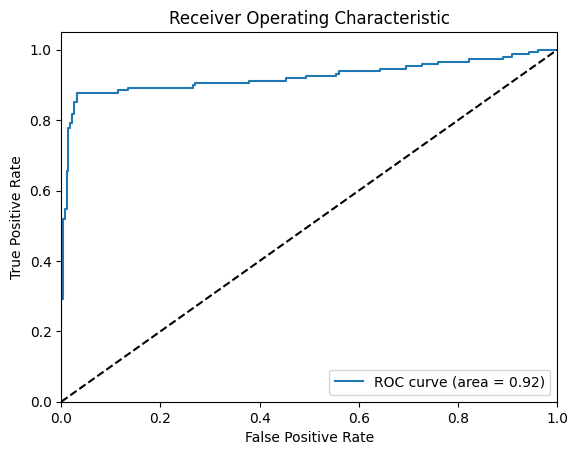

PR AUC: 0.9203286170853049


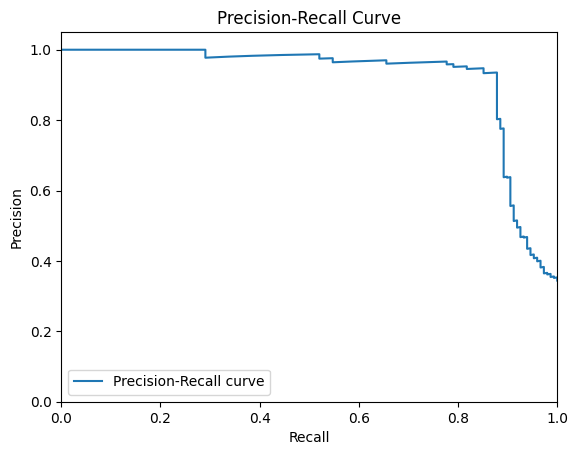

100%|██████████| 12/12 [00:14<00:00,  1.25s/it]


In [ ]:
results = {}

for name, model in tqdm(models.items()):
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred  = model.predict(X_test)

    results[name] = {
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Test Accuracy": accuracy_score(y_test, test_pred),
        "Train Precision": precision_score(y_train, train_pred),
        "Test Precision": precision_score(y_test, test_pred),
        "Train Recall": recall_score(y_train, train_pred),
        "Test Recall": recall_score(y_test, test_pred),
        "Train F1 Score": f1_score(y_train, train_pred),
        "Test F1 Score": f1_score(y_test, test_pred),
        "Train Balanced Accuracy": balanced_accuracy_score(y_train, train_pred),
        "Test Balanced Accuracy": balanced_accuracy_score(y_test, test_pred)

    }

    cm = confusion_matrix(y_test, test_pred)
    print("\nConfusion Matrix:\n", cm)

    plt.figure(figsize=(6,4))
    sns.heatmap(cm,annot=True,fmt="d",cmap='Blues',cbar=False,
                xticklabels=['Not Diagnosis','Diagnosis']
                ,yticklabels=['Not Diagnosis','Diagnosis'])
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title('Confusion Matrix')
    plt.show()

    # Full classification report
    print("\nClassification Report:\n")
    print(classification_report(y_test, test_pred,target_names=['Not Diagnosis','Diagnosis'],zero_division=0))

    y_pred_prob = model.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_pred_prob)
    print("ROC-AUC:", roc_auc)

    # ROC curve
    fpr, tpr, roc_thresholds = roc_curve(y_test, y_pred_prob)
    plt.figure()
    plt.plot(fpr, tpr, label='ROC curve (area = {:.2f})'.format(roc_auc))
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()

    pr_auc = average_precision_score(y_test, y_pred_prob)
    print("PR AUC:", pr_auc)

    precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, y_pred_prob)
    plt.figure()
    plt.plot(recall_vals, precision_vals, label='Precision-Recall curve')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend(loc="lower left")
    plt.show()



In [ ]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by="Test F1 Score", ascending=False)
results_df

,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1 Score,Test F1 Score,Train Balanced Accuracy,Test Balanced Accuracy
CatBoost,0.989529,0.934884,0.985294,0.941176,0.985294,0.864865,0.985294,0.901408,0.988582,0.918248
LightGBM,1.000000,0.927907,1.000000,0.933333,1.000000,0.851351,1.000000,0.890459,1.000000,0.909718
XGBoost,1.000000,0.925581,1.000000,0.953125,1.000000,0.824324,1.000000,0.884058,1.000000,0.901524
Gradient Boosting,0.973822,0.923256,0.967051,0.932331,0.959150,0.837838,0.963084,0.882562,0.970542,0.902961
Hist Gradient Boosting,1.000000,0.923256,1.000000,0.938931,1.000000,0.831081,1.000000,0.881720,1.000000,0.901356
Random Forest,1.000000,0.916279,1.000000,0.951613,1.000000,0.797297,1.000000,0.867647,1.000000,0.888010
AdaBoost,0.947062,0.902326,0.929160,0.895522,0.921569,0.810811,0.925349,0.851064,0.941362,0.880583
Decision Tree,1.000000,0.860465,1.000000,0.828358,1.000000,0.750000,1.000000,0.787234,1.000000,0.834220
Extra Trees,1.000000,0.832558,1.000000,0.872549,1.000000,0.601351,1.000000,0.712000,1.000000,0.777626
Logistic Regression,0.855148,0.790698,0.812392,0.754386,0.771242,0.581081,0.791282,0.656489,0.836389,0.740895
